Neste notebook vamos construir um pipeline simples para entender o dataset da competição e treinar um primeiro modelo preditivo. O objetivo aqui é te equipar com as ferramentas para testar suas próprias ideias.

Célula 0 - Conexão ao drive

In [149]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Célula 1 - Nesta etapa, importamos as bibliotecas utilizadas ao longo do notebook e definimos uma semente fixa de aleatoriedade para garantir a reprodutibilidade dos experimentos. A fixação das seeds assegura que os resultados obtidos possam ser replicados em diferentes execuções, atendendo ao critério de reprodutibilidade exigido pela atividade.

In [185]:
# ============================
# Imports e configuração geral
# ============================

import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import folium

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# ============================
# Reprodutibilidade
# ============================

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

Célula 2 - Os dados foram carregados a partir de arquivos CSV e submetidos a uma verificação inicial de integridade, incluindo inspeção das colunas, análise de valores ausentes e detecção de duplicatas. Essas etapas garantem que o conjunto de dados esteja consistente antes das fases de pré-processamento e modelagem.

In [186]:
# ============================
# Carregamento dos dados
# ============================

TRAIN_PATH = "/content/drive/MyDrive/Classroom/[CTE-IA] Tópicos Especiais em Aprendizado de Máquina Profs. José Macêdo (DC UFC) e Régis Pires (Quixadá UFC)/Desafio Kaggle/train.csv"
TEST_PATH = "/content/drive/MyDrive/Classroom/[CTE-IA] Tópicos Especiais em Aprendizado de Máquina Profs. José Macêdo (DC UFC) e Régis Pires (Quixadá UFC)/Desafio Kaggle/test.csv"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

# ============================
# Verificação inicial
# ============================

print("\nColunas do conjunto de treino:")
display(train.columns)

print("\nColunas do conjunto de teste:")
display(test.columns)

# ============================
# Checagem de valores ausentes
# ============================

print("\nValores ausentes no treino:")
display(train.isnull().sum())

print("\nValores ausentes no teste:")
display(test.isnull().sum())

# ============================
# Checagem de duplicatas
# ============================

print("\nDuplicatas no treino:", train.duplicated().sum())
print("Duplicatas no teste:", test.duplicated().sum())

Train shape: (12050, 9)
Test shape: (3013, 7)

Colunas do conjunto de treino:


Index(['trajectory_id', 'user_id', 'n_points', 'prefix_ratio',
       'prefix_n_points', 'path_lat', 'path_lon', 'dest_lat', 'dest_lon'],
      dtype='object')


Colunas do conjunto de teste:


Index(['trajectory_id', 'user_id', 'n_points', 'prefix_ratio',
       'prefix_n_points', 'path_lat', 'path_lon'],
      dtype='object')


Valores ausentes no treino:


,0
trajectory_id,0
user_id,0
n_points,0
prefix_ratio,0
prefix_n_points,0
path_lat,0
path_lon,0
dest_lat,0
dest_lon,0



Valores ausentes no teste:


,0
trajectory_id,0
user_id,0
n_points,0
prefix_ratio,0
prefix_n_points,0
path_lat,0
path_lon,0



Duplicatas no treino: 0
Duplicatas no teste: 0


In [187]:
train

,trajectory_id,user_id,n_points,prefix_ratio,prefix_n_points,path_lat,path_lon,dest_lat,dest_lon
0,000_20081023025304,0,908,0.3,272,"[39.984702, 39.984683, 39.984686, 39.984688, 3...","[116.318417, 116.31845, 116.318417, 116.318385...",40.009328,116.320887
1,000_20081024020959,0,244,0.3,73,"[40.008304, 40.008413, 40.007171, 40.007209, 4...","[116.319876, 116.319962, 116.319458, 116.31948...",40.009209,116.321162
2,000_20081026134407,0,745,0.3,223,"[39.907414, 39.907374, 39.907027, 39.907006, 3...","[116.370017, 116.370074, 116.37036, 116.370415...",39.926426,116.320399
3,000_20081029093038,0,182,0.3,54,"[39.991364, 39.991551, 39.991821, 39.991771, 3...","[116.326605, 116.326653, 116.326695, 116.32667...",39.966701,116.327688
4,000_20081103232153,0,2231,0.3,669,"[39.996948, 39.996849, 39.994409, 39.995076, 3...","[116.325747, 116.325763, 116.326968, 116.32662...",39.999659,116.324747
...,...,...,...,...,...,...,...,...,...
12045,179_20081109120329,179,812,0.3,243,"[39.988636, 39.989413, 39.989298, 39.989162, 3...","[116.330106, 116.329967, 116.33002, 116.330011...",40.088192,116.305456
12046,179_20081115015705,179,2402,0.3,720,"[40.08777, 40.087713, 40.087775, 40.087813, 40...","[116.305671, 116.30599, 116.304837, 116.304419...",40.009203,116.320685
12047,179_20081117025429,179,230,0.3,69,"[40.087975, 40.088223, 40.088221, 40.088174, 4...","[116.303741, 116.303499, 116.303511, 116.30357...",40.090134,116.296708
12048,179_20081117030421,179,2769,0.3,830,"[40.087586, 40.087553, 40.08754, 40.087511, 40...","[116.298273, 116.298083, 116.297833, 116.29763...",40.087012,116.304162


In [188]:
test

,trajectory_id,user_id,n_points,prefix_ratio,prefix_n_points,path_lat,path_lon
0,000_20081028003826,0,1477,0.3,443,"[40.01229, 40.012594, 40.012581, 40.012453, 40...","[116.297072, 116.297269, 116.297263, 116.29717..."
1,000_20081112023003,0,681,0.3,204,"[39.995805, 39.995833, 39.995981, 39.995929, 3...","[116.326236, 116.326268, 116.32611, 116.326169..."
2,000_20081118095400,0,254,0.3,76,"[40.010603, 40.010601, 40.010586, 40.010692, 4...","[116.322627, 116.322636, 116.322561, 116.32261..."
3,000_20081119112035,0,419,0.3,125,"[40.001038, 40.000522, 40.000638, 40.000662, 4...","[116.324874, 116.324638, 116.324694, 116.32472..."
4,000_20081212042525,0,338,0.3,101,"[40.007451, 40.00743, 40.008937, 40.008948, 40...","[116.323341, 116.32339, 116.321548, 116.321455..."
...,...,...,...,...,...,...,...
3008,179_20081109014530,179,459,0.3,137,"[40.087961, 40.087904, 40.087839, 40.087815, 4...","[116.304268, 116.304239, 116.304208, 116.30418..."
3009,179_20081115105653,179,2404,0.3,721,"[39.998501, 39.99875, 39.998781, 39.99879, 39....","[116.322893, 116.322919, 116.322923, 116.32294..."
3010,179_20081116065153,179,1236,0.3,370,"[39.990422, 39.990357, 39.990258, 39.990018, 3...","[116.312451, 116.312547, 116.312646, 116.31276..."
3011,180_20090528211734,180,45993,0.3,13797,"[39.11965, 39.119204, 39.118791, 39.118545, 39...","[116.369462, 116.369434, 116.369529, 116.36957..."



Cada linha contém:

* `trajectory_id`: id único da trajetória
* `user_id`: pessoa que gerou o caminho
* `n_points`: número total de pontos da trajetória original
* `prefix_ratio`: porcentagem usada como prefixo
* `prefix_n_points`: quantidade de pontos no prefixo
* `path_lat` e `path_lon`: **listas (sequências)** de pontos de latitude e longitude
* `dest_lat` e `dest_lon`: destino real (somente no train)

**O prefixo é a parte inicial do caminho**, e é isso que damos ao modelo para prever o destino final.

Por que prefixo?

Porque na vida real, normalmente queremos prever algo ANTES do trajeto terminar.
Exemplo: “Para onde essa pessoa vai?”, usando apenas o começo do trajeto.

## EDA — Análise Exploratória
Vamos começar entendendo o conjunto de dados. Vamos verificar pontos mais básicos.

#### Quantas trajetórias cada usuário tem?

1.   Item da lista
2.   Item da lista



Isso ajuda a perceber se alguns usuários estão super-representados.

Célula 3 - A análise da distribuição de trajetórias por usuário indica que alguns indivíduos contribuem com um número significativamente maior de trajetórias do que outros. Esse comportamento sugere dependência entre amostras associadas ao mesmo usuário, o que pode introduzir vieses caso o identificador do usuário seja utilizado diretamente como atributo. Por esse motivo, o user_id não será utilizado como variável explicativa no modelo.

In [189]:
# ============================
# Distribuição de trajetórias por usuário
# ============================

user_counts = train["user_id"].value_counts()
print(user_counts.head(10))

print("\nNúmero total de usuários:", train["user_id"].nunique())
print("Média de trajetórias por usuário:", user_counts.mean())
print("Máximo de trajetórias por usuário:", user_counts.max())


user_id
128    1464
153    1460
163     573
25      477
41      392
62      363
68      319
85      296
17      285
167     273
Name: count, dtype: int64

Número total de usuários: 161
Média de trajetórias por usuário: 74.84472049689441
Máximo de trajetórias por usuário: 1464


#### Quantos pontos tem cada prefixo?


Trajetórias com poucos pontos são difíceis de usar, enquanto trajetórias longas carregam mais informação.

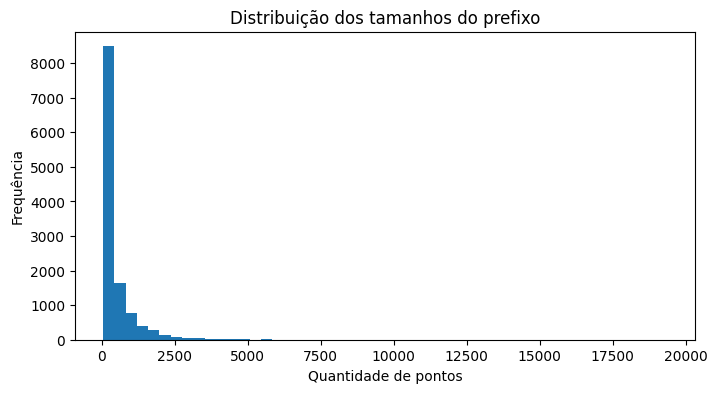

In [190]:
plt.figure(figsize=(8,4))
plt.hist(train["prefix_n_points"], bins=50)
plt.title("Distribuição dos tamanhos do prefixo")
plt.xlabel("Quantidade de pontos")
plt.ylabel("Frequência")
plt.show()

Célula 4 - Para investigar a existência de padrões espaciais recorrentes, os destinos finais foram agrupados por aproximação espacial, utilizando arredondamento para quatro casas decimais nas coordenadas geográficas. Observa-se que uma fração significativa das trajetórias termina em um conjunto reduzido de pontos, indicando a presença de destinos recorrentes, como locais de residência ou trabalho. Esse comportamento sugere que o modelo pode se beneficiar da identificação de padrões globais de deslocamento.

#### Quais são os destinos mais comuns?

Não significa que muitos destinos são iguais, só que algumas pessoas têm rotinas estáveis.

In [191]:
# ============================
# Análise de destinos recorrentes
# ============================

# Agrupamento aproximado dos destinos (≈ 11m de precisão)
train["dest_pair"] = (
    train["dest_lat"].round(4).astype(str) + "," +
    train["dest_lon"].round(4).astype(str)
)

dest_counts = train["dest_pair"].value_counts()

print("Top 10 destinos mais frequentes:")
display(dest_counts.head(10))

print("\nPercentual das trajetórias nos 10 destinos mais comuns:")
print(f"{dest_counts.head(10).sum() / len(train) * 100:.2f}%")

Top 10 destinos mais frequentes:


,count
dest_pair,
"39.9717,116.4413",83
"39.9755,116.3306",59
"39.9756,116.3308",58
"39.9757,116.3309",57
"39.9755,116.3305",55
"40.076,116.3232",47
"39.9757,116.3308",41
"39.9756,116.3309",38
"40.077,116.3255",37



Percentual das trajetórias nos 10 destinos mais comuns:
4.25%


In [157]:
# train["dest_pair"] = (
#     train["dest_lat"].round(4).astype(str) + "," +
#     train["dest_lon"].round(4).astype(str)
# )

# train["dest_pair"].value_counts().head(10)

,count
dest_pair,
"39.9717,116.4413",83
"39.9755,116.3306",59
"39.9756,116.3308",58
"39.9757,116.3309",57
"39.9755,116.3305",55
"40.076,116.3232",47
"39.9757,116.3308",41
"39.9756,116.3309",38
"40.077,116.3255",37


Célula 5 - Foi realizada uma análise exploratória do tamanho dos prefixos de trajetória disponíveis no conjunto de dados. Observa-se uma variabilidade significativa no número de pontos observados por trajetória, o que reforça a necessidade de uma representação flexível capaz de lidar com sequências de comprimento variável. A seleção da trajetória mais longa por usuário foi utilizada exclusivamente para fins exploratórios e não influencia o processo de treinamento dos modelos.

Selecionando uma trajetória por usuário

Escolhemos intencionalmente a mais longa, pois normalmente é a que melhor mostra os padrões daquele usuário.

In [192]:
# ============================
# Análise do tamanho das trajetórias (EDA)
# ============================

# Seleciona, para cada usuário, a trajetória com maior número de pontos observados
best_traj = (
    train.sort_values("prefix_n_points", ascending=False)
         .groupby("user_id")
         .head(1)
)
display(best_traj.head(10))

print("Resumo do número de pontos observados:")
print(train["prefix_n_points"].describe())

,trajectory_id,user_id,n_points,prefix_ratio,prefix_n_points,path_lat,path_lon,dest_lat,dest_lon,dest_pair
8713,135_20090124065103,135,64483,0.3,19344,"[39.894227, 39.893738, 39.893912, 39.893986, 3...","[116.314732, 116.314578, 116.314656, 116.31465...",26.389065,111.620466,"26.3891,111.6205"
9370,144_20090706033310,144,64168,0.3,19250,"[36.628148, 36.628126, 36.628186, 36.628291, 3...","[101.798381, 101.798254, 101.798088, 101.79799...",32.429274,91.593658,"32.4293,91.5937"
5505,074_20120128104325,74,62192,0.3,18657,"[26.6585, 26.6584816666667, 26.6584433333333, ...","[115.0283, 115.02802, 115.027743333333, 115.02...",39.886777,116.337433,"39.8868,116.3374"
960,010_20080928160000,10,56785,0.3,17035,"[37.936471, 37.936084, 37.935304, 37.934926, 3...","[114.500004, 114.500086, 114.500256, 114.50036...",37.240244,100.300016,"37.2402,100.3"
9020,141_20111022031803,141,56780,0.3,17034,"[39.9924283333333, 39.992435, 39.9923466666667...","[116.198001666667, 116.198006666667, 116.19769...",39.974798,116.339615,"39.9748,116.3396"
4933,065_20111005004827,65,52407,0.3,15722,"[39.96297, 39.9629483333333, 39.96297, 39.9629...","[116.31996, 116.319906666667, 116.319566666667...",39.907397,116.182378,"39.9074,116.1824"
11583,165_20111119010003,165,45335,0.3,13600,"[39.9769616666667, 39.97696, 39.9768283333333,...","[116.33081, 116.330815, 116.33051, 116.3305083...",39.980128,116.303763,"39.9801,116.3038"
6947,124_20081001230824,124,45137,0.3,13541,"[29.648361, 29.648375, 29.648328, 29.64835, 29...","[91.089951, 91.089753, 91.089526, 91.089336, 9...",37.298966,95.790848,"37.299,95.7908"
5050,067_20110522080505,67,44150,0.3,13245,"[31.8403833333333, 31.8403683333333, 31.840358...","[117.250636666667, 117.250608333333, 117.25062...",39.978818,116.331882,"39.9788,116.3319"
4337,050_20090824031656,50,36224,0.3,10867,"[39.99440765, 39.99440765, 39.9943924, 39.9943...","[116.199539183333, 116.199546816667, 116.19953...",33.573009,114.038048,"33.573,114.038"


Resumo do número de pontos observados:
count    12050.000000
mean       491.505394
std        914.466605
min         45.000000
25%        105.000000
50%        211.000000
75%        531.000000
max      19344.000000
Name: prefix_n_points, dtype: float64


Célula 6 - A visualização espacial de trajetórias reais permite compreender padrões típicos de deslocamento, como direções predominantes, densidade de caminhos e regiões frequentemente percorridas. Observa-se que muitas trajetórias compartilham segmentos iniciais semelhantes e convergem para áreas específicas da cidade, reforçando a hipótese de destinos recorrentes. Esta análise é utilizada exclusivamente para fins exploratórios e não interfere no processo de treinamento dos modelos.

## Visualizando trajetórias no mapa

Para visualizar rotas, vamos usar o Folium, que cria mapas interativos. Vamos mostrar a maior trajetória de cada usuário (como exemplo visual).

In [193]:
# ============================
# Visualização espacial de trajetórias (EDA)
# ============================

# mapa centralizado em Pequim (região do dataset)
m = folium.Map(location=[39.9, 116.3], zoom_start=11)

# folium.TileLayer(tiles="OpenStreetMap", opacity=0.3, name="OSM Esmaecido").add_to(m)
folium.TileLayer(tiles="CartoDB Dark_Matter", name="Mapa Esmaecido").add_to(m)  # ou CartoDB Positron

N = len(best_traj)

# Tab20 tem 20 cores discretas internas
cmap = plt.colormaps["tab20"]

# linspace(0, 1, N) gera N valores igualmente espaçados entre 0 e 1
# Para N=20, retorna exatamente os 20 slots do Tab20
colors_list = [mcolors.to_hex(cmap(i)) for i in np.linspace(0, 1, N)]

for (color, (_, row)) in zip(colors_list, best_traj.iterrows()):
    lat_list = json.loads(row["path_lat"])
    lon_list = json.loads(row["path_lon"])
    coords = list(zip(lat_list, lon_list))

    folium.PolyLine(coords, color=color, weight=2).add_to(m)

In [194]:
m

Output hidden; open in https://colab.research.google.com to view.

Célula 7 - Como modelo baseline, foram extraídas características simples e diretamente interpretáveis a partir do prefixo da trajetória. Essas incluem a posição inicial, a posição final observada e o deslocamento espacial acumulado, além do número de pontos disponíveis. Essas variáveis capturam informações básicas de localização e direção, servindo como referência inicial para modelos mais complexos.

## Construindo o modelo baseline

prever o destino final da trajetória usando apenas o prefixo.

Como ponto de partida, vamos criar um modelo simples usando features básicas da rota. A abordagem desse exemplo será extraindo features básicas das rotas.

Vamos extrair:

* posição inicial
* posição final do prefixo

In [195]:
# def haversine_np(lat1, lon1, lat2, lon2):
#     R = 6371000
#     lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
#     dlat = lat2 - lat1
#     dlon = lon2 - lon1
#     a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
#     return 2 * R * np.arcsin(np.sqrt(a))

# def bearing(lat1, lon1, lat2, lon2):
#     lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
#     dlon = lon2 - lon1
#     x = np.sin(dlon) * np.cos(lat2)
#     y = np.cos(lat1)*np.sin(lat2) - np.sin(lat1)*np.cos(lat2)*np.cos(dlon)
#     return np.arctan2(x, y)

def extract_features(df):
    feats = []

    for _, row in df.iterrows():
        lats = json.loads(row["path_lat"])
        lons = json.loads(row["path_lon"])

        # ponto inicial
        start_lat = lats[0]
        start_lon = lons[0]

        # ponto final do prefixo
        end_lat = lats[-1]
        end_lon = lons[-1]

        dist = haversine_np(start_lat, start_lon, end_lat, end_lon)
        dirc = bearing(start_lat, start_lon, end_lat, end_lon)

        feats.append({
            "start_lat": start_lat,
            "start_lon": start_lon,
            "end_lat": end_lat,
            "end_lon": end_lon,
            "delta_lat": end_lat - start_lat, # deslocamento total latitude
            "delta_lon": end_lon - start_lon, # deslocamento total longitude,
            # "distance": dist,
            # "bearing": dirc,
            "n_points": len(lats) # número de pontos observados
        })

    return pd.DataFrame(feats)

In [162]:
# def extract_features(df):
#     feats = []

#     for _, row in df.iterrows():
#         lats = json.loads(row["path_lat"])
#         lons = json.loads(row["path_lon"])

#         # ponto inicial
#         start_lat = lats[0]
#         start_lon = lons[0]

#         # ponto final do prefixo
#         end_lat = lats[-1]
#         end_lon = lons[-1]

#         feats.append({
#             "start_lat": start_lat,
#             "start_lon": start_lon,
#             "end_lat": end_lat,
#             "end_lon": end_lon,
#         })

#     return pd.DataFrame(feats)

Célula 8 - O conjunto de dados foi particionado em subconjuntos de treino e validação utilizando uma divisão aleatória estratificada simples, com 80% das trajetórias destinadas ao treinamento e 20% à validação. Optou-se por essa abordagem por simplicidade e por não utilizar o identificador do usuário como variável explicativa, reduzindo o risco de vazamento de informação.

Primeiro, vamos criar um conjunto de treino e validação.


In [196]:
train

,trajectory_id,user_id,n_points,prefix_ratio,prefix_n_points,path_lat,path_lon,dest_lat,dest_lon,dest_pair
0,000_20081023025304,0,908,0.3,272,"[39.984702, 39.984683, 39.984686, 39.984688, 3...","[116.318417, 116.31845, 116.318417, 116.318385...",40.009328,116.320887,"40.0093,116.3209"
1,000_20081024020959,0,244,0.3,73,"[40.008304, 40.008413, 40.007171, 40.007209, 4...","[116.319876, 116.319962, 116.319458, 116.31948...",40.009209,116.321162,"40.0092,116.3212"
2,000_20081026134407,0,745,0.3,223,"[39.907414, 39.907374, 39.907027, 39.907006, 3...","[116.370017, 116.370074, 116.37036, 116.370415...",39.926426,116.320399,"39.9264,116.3204"
3,000_20081029093038,0,182,0.3,54,"[39.991364, 39.991551, 39.991821, 39.991771, 3...","[116.326605, 116.326653, 116.326695, 116.32667...",39.966701,116.327688,"39.9667,116.3277"
4,000_20081103232153,0,2231,0.3,669,"[39.996948, 39.996849, 39.994409, 39.995076, 3...","[116.325747, 116.325763, 116.326968, 116.32662...",39.999659,116.324747,"39.9997,116.3247"
...,...,...,...,...,...,...,...,...,...,...
12045,179_20081109120329,179,812,0.3,243,"[39.988636, 39.989413, 39.989298, 39.989162, 3...","[116.330106, 116.329967, 116.33002, 116.330011...",40.088192,116.305456,"40.0882,116.3055"
12046,179_20081115015705,179,2402,0.3,720,"[40.08777, 40.087713, 40.087775, 40.087813, 40...","[116.305671, 116.30599, 116.304837, 116.304419...",40.009203,116.320685,"40.0092,116.3207"
12047,179_20081117025429,179,230,0.3,69,"[40.087975, 40.088223, 40.088221, 40.088174, 4...","[116.303741, 116.303499, 116.303511, 116.30357...",40.090134,116.296708,"40.0901,116.2967"
12048,179_20081117030421,179,2769,0.3,830,"[40.087586, 40.087553, 40.08754, 40.087511, 40...","[116.298273, 116.298083, 116.297833, 116.29763...",40.087012,116.304162,"40.087,116.3042"


In [197]:
# ============================
# Divisão treino / validação
# ============================

# divide o treino em treino interno + validação (20%)
train_split, val_split = train_test_split(
    train,
    test_size=0.2,
    random_state=SEED
)

# Extração de atributos
X_train = extract_features(train_split)
X_val   = extract_features(val_split)

# Variáveis alvo (latitude e longitude finais)
y_train_lat = train_split["dest_lat"]
y_train_lon = train_split["dest_lon"]

y_val_lat = val_split["dest_lat"]
y_val_lon = val_split["dest_lon"]


In [165]:
# from sklearn.model_selection import train_test_split

# # divide o treino em treino interno + validação (20%)
# train_split, val_split = train_test_split(train, test_size=0.2, random_state=42)

# # extrai features
# X_train = extract_features(train_split)
# X_val   = extract_features(val_split)

# # variáveis alvo
# y_train_lat = train_split["dest_lat"]
# y_train_lon = train_split["dest_lon"]

# y_val_lat = val_split["dest_lat"]
# y_val_lon = val_split["dest_lon"]

In [198]:
X_train

,start_lat,start_lon,end_lat,end_lon,delta_lat,delta_lon,distance,bearing,n_points
0,40.007441,116.319807,40.000169,116.323907,-0.007272,0.004100,880.797169,2.733889,84
1,39.975152,116.339428,39.986860,116.400027,0.011708,0.060598,5324.822354,1.323456,227
2,40.005827,116.322733,39.985258,116.326965,-0.020569,0.004232,2315.405870,2.985234,400
3,39.984868,116.320260,39.966442,116.346793,-0.018427,0.026533,3051.231131,2.306903,1045
4,39.975014,116.329294,39.932538,116.465412,-0.042476,0.136118,12526.919944,1.956629,1141
...,...,...,...,...,...,...,...,...,...
9635,39.975912,116.330100,39.977186,116.374753,0.001274,0.044653,3807.496163,1.533331,500
9636,39.968720,116.420074,39.997107,116.414651,0.028387,-0.005423,3190.128519,-0.145318,1155
9637,39.509603,118.664780,39.349204,118.623096,-0.160399,-0.041684,18191.329180,-2.943263,2610
9638,40.002644,116.344202,39.959896,116.358988,-0.042748,0.014786,4917.477612,2.882429,1378


In [199]:
X_val

,start_lat,start_lon,end_lat,end_lon,delta_lat,delta_lon,distance,bearing,n_points
0,40.075973,116.323267,40.045782,116.328783,-0.030192,0.005517,3389.833991,3.002614,186
1,39.900933,116.425197,37.254487,116.389963,-2.646447,-0.035233,294287.376551,-3.130992,2572
2,39.971957,116.300692,39.954170,116.302695,-0.017787,0.002003,1985.135393,3.055469,228
3,31.592925,120.311418,31.569303,120.301652,-0.023622,-0.009767,2784.775895,-2.802888,491
4,39.975679,116.330749,39.974984,116.336443,-0.000695,0.005694,491.307556,1.728716,111
...,...,...,...,...,...,...,...,...,...
2405,39.984617,116.311558,39.895390,116.298752,-0.089227,-0.012807,9981.452073,-3.031915,894
2406,39.975378,116.330402,39.952405,116.329427,-0.022973,-0.000975,2555.865525,-3.109070,82
2407,39.827120,116.065377,39.936445,116.349764,0.109325,0.284387,27140.700052,1.104788,7623
2408,39.952358,116.265328,39.943660,116.268273,-0.008698,0.002945,999.224198,2.887613,128


In [200]:
y_train_lat

,dest_lat
10,40.005403
7889,40.076950
6994,40.007402
1426,39.999587
9736,39.926870
...,...
11964,40.051780
5191,39.996858
5390,39.509763
860,40.002668


In [201]:
y_train_lon

,dest_lon
10,116.321070
7889,116.325677
6994,116.322420
1426,116.375953
9736,116.471225
...,...
11964,116.398868
5191,116.415419
5390,118.664428
860,116.343973


Célula 9 - Foram treinados dois modelos independentes de Random Forest, um para latitude e outro para longitude, permitindo capturar relações não lineares entre as características do prefixo da trajetória e o destino final. Os hiperparâmetros foram ajustados de forma a controlar a complexidade do modelo e reduzir o risco de sobreajuste, buscando maior capacidade de generalização.



In [202]:
# ============================
# Treinamento do modelo
# ============================

model_lat = RandomForestRegressor(
    n_estimators=300, # Reduz variância
    max_depth=15, # Evita árvores excessivamente específicas
    min_samples_leaf=5, # Suaviza previsões
    random_state=SEED,
    n_jobs=-1
)

model_lon = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=5,
    random_state=SEED,
    n_jobs=-1
)

model_lat.fit(X_train, y_train_lat)
model_lon.fit(X_train, y_train_lon)


RandomForestRegressor(max_depth=15, min_samples_leaf=5, n_estimators=300,
                      n_jobs=-1, random_state=42)

In [171]:
# model_lat = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
# model_lon = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)

# model_lat.fit(X_train, y_train_lat)
# model_lon.fit(X_train, y_train_lon)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

Célula 10 - O desempenho do modelo foi avaliado no conjunto de validação utilizando a distância Haversine, métrica oficial da competição. O erro médio obtido indica que, em média, o destino final é estimado a uma distância de aproximadamente 22,17 km do destino real, enquanto o desvio padrão fornece uma medida da variabilidade das previsões. Esses resultados estabelecem um baseline quantitativo para comparação com abordagens mais elaboradas.

In [203]:
pred_lat_val = model_lat.predict(X_val)
pred_lon_val = model_lon.predict(X_val)

pred_lat_val, pred_lon_val

(array([39.98016292, 32.5034423 , 39.93666946, ..., 39.79926646,
        39.92495817, 39.90653305]),
 array([116.32857212, 116.11056806, 116.31812543, ..., 116.51537967,
        116.30086006, 116.40663427]))

Vamos avaliar a qualidade das predições (erro) desse modelo no conjunto de validação. Primeiro vamos implementar a métrica haversine ponto a ponto.  


In [207]:
def haversine(lat1, lon1, lat2, lon2):
    """
    Retorna a distância Haversine em metros entre dois pontos (lat, lon).
    """
    R = 6371000  # raio da Terra em metros

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c


In [208]:
errors = haversine(
    y_val_lat.values,
    y_val_lon.values,
    pred_lat_val,
    pred_lon_val
)

mean_error = errors.mean()

print(f"Distância Haversine média em quilômetros no conjunto de validação: {mean_error/1000:.2f} km")
print(f"Desvio padrão do erro: {errors.std()/1000:.2f} km")

Distância Haversine média em quilômetros no conjunto de validação: 22.13 km
Desvio padrão do erro: 137.30 km


Célula 11 - A visualização espacial dos erros no conjunto de validação permite uma interpretação qualitativa do desempenho do modelo. Observa-se que, em muitos casos, as previsões aproximam-se do destino real, enquanto erros mais elevados tendem a ocorrer em trajetórias longas ou com mudanças abruptas de direção. Essa análise é utilizada exclusivamente para fins exploratórios e não influencia o processo de treinamento.

In [175]:
# ============================
# Visualização do erro espacial (validação)
# ============================

# Construir um DataFrame com verdade e predição lado a lado
val_vis = val_split.copy().reset_index(drop=True)
val_vis["pred_lat"] = pred_lat_val
val_vis["pred_lon"] = pred_lon_val

# Para não deixar o mapa pesado, pegamos uma amostra de trajetórias
N_SAMPLE = 50  # você pode ajustar
if len(val_vis) > N_SAMPLE:
    val_sample = val_vis.sample(N_SAMPLE, random_state=42)
else:
    val_sample = val_vis

In [176]:
m = folium.Map(location=[39.9, 116.3], zoom_start=11)
folium.TileLayer(tiles="CartoDB Positron", name="Mapa Esmaecido").add_to(m)  # ou CartoDB Dark_Matter

# Adicionar pontos e linhas no mapa
for _, row in val_sample.iterrows():
    real_lat = row["dest_lat"]
    real_lon = row["dest_lon"]
    pred_lat = row["pred_lat"]
    pred_lon = row["pred_lon"]

    # Marcador do destino real (verde)
    folium.CircleMarker(
        location=[real_lat, real_lon],
        radius=3,
        color="green",
        fill=True,
        fill_color="green",
        fill_opacity=0.7,
        popup=f"REAL: ({real_lat:.5f}, {real_lon:.5f})"
    ).add_to(m)

    # Marcador do destino previsto (vermelho)
    folium.CircleMarker(
        location=[pred_lat, pred_lon],
        radius=3,
        color="red",
        fill=True,
        fill_color="red",
        fill_opacity=0.7,
        popup=f"PREDITO: ({pred_lat:.5f}, {pred_lon:.5f})"
    ).add_to(m)

    # Linha ligando real ↔ previsto
    folium.PolyLine(
        locations=[[real_lat, real_lon], [pred_lat, pred_lon]],
        color="blue",
        weight=1,
        opacity=0.5
    ).add_to(m)

In [177]:
m

Célula 12 - Usando os modelos treinados no conjunto de treino interno, realizamos a geração de uma submissão preliminar para o Kaggle. Essa etapa tem como objetivo verificar o desempenho do modelo baseline no leaderboard e validar o pipeline de predição e submissão. O treinamento final com todo o conjunto de treino será realizado posteriormente.

## Usando os modelos treinados para obter as predições de latitude e longitude

In [178]:
X_test   = extract_features(test)
pred_lat = model_lat.predict(X_test)
pred_lon = model_lon.predict(X_test)

In [179]:
X_test

,start_lat,start_lon,end_lat,end_lon
0,40.012290,116.297072,40.006808,116.295803
1,39.995805,116.326236,39.999669,116.324579
2,40.010603,116.322627,40.002322,116.321584
3,40.001038,116.324874,40.005946,116.319207
4,40.007451,116.323341,39.999290,116.320237
...,...,...,...,...
3008,40.087961,116.304268,40.090206,116.301860
3009,39.998501,116.322893,39.991718,116.330416
3010,39.990422,116.312451,40.010136,116.329207
3011,39.119650,116.369462,34.924657,115.582756


In [180]:
submission = pd.DataFrame({
    "trajectory_id": test["trajectory_id"],
    "latitude_pred": pred_lat,
    "longitude_pred": pred_lon
})

submission.to_csv("submission1.csv", index=False)
submission.head()

,trajectory_id,latitude_pred,longitude_pred
0,000_20081028003826,40.002660,116.313433
1,000_20081112023003,39.991343,116.318032
2,000_20081118095400,40.001525,116.326078
3,000_20081119112035,40.004401,116.329984
4,000_20081212042525,39.991039,116.327993


Célula 13 - Como baseline adicional, foi construída uma estratégia ingênua que prediz o destino final de todas as trajetórias como sendo o ponto médio (latitude e longitude médias) dos destinos observados no conjunto de treino. Esse modelo serve apenas como referência inferior de desempenho, permitindo quantificar o ganho obtido pelos modelos baseados em aprendizado de máquina.

## Obtendo a latitude e longitude médias para o conjunto de dados de treino

In [181]:
media_lat_train = train['dest_lat'].mean()
media_lat_train

np.float64(39.540600585811816)

In [182]:
media_lon_train = train['dest_lon'].mean()
media_lon_train

np.float64(113.8514452149134)

## Gerando uma submissão (ruim) baseada na média

In [183]:
submission_media = pd.DataFrame({
    "trajectory_id": test["trajectory_id"],
    "latitude_pred": media_lat_train,
    "longitude_pred": media_lon_train
})

submission_media.to_csv("submission-media.csv", index=False)
submission_media.head()

,trajectory_id,latitude_pred,longitude_pred
0,000_20081028003826,39.540601,113.851445
1,000_20081112023003,39.540601,113.851445
2,000_20081118095400,39.540601,113.851445
3,000_20081119112035,39.540601,113.851445
4,000_20081212042525,39.540601,113.851445


In [184]:
# from google.colab import files
# files.download('submission1.csv')